# YOLOv11 Kaggle Training Notebook (v2)
## Real-time Student Behavior Detection (Kaggle)

This notebook is designed for Kaggle runtime with optional Google Drive ZIP download and Kaggle paths.

## 1. Runtime Check and Dependencies

In [1]:
import os
import sys, platform
print('Python:', sys.version)
print('Executable:', sys.executable)
print('Platform:', platform.platform())
print('Kaggle env:', os.environ.get('KAGGLE_KERNEL_RUN_TYPE') is not None)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Executable: /usr/bin/python3
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Kaggle env: True


In [2]:
%pip install -q ultralytics opencv-python pyyaml matplotlib pillow gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import json
import yaml
import shutil
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

KAGGLE_INPUT_ROOT = Path('/kaggle/input')
KAGGLE_WORKING_ROOT = Path('/kaggle/working')
RUNS_ROOT = KAGGLE_WORKING_ROOT / 'fyp_runs'
RUNS_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR = RUNS_ROOT / 'classroom_model_v2_kaggle'
BEST_WEIGHTS = RUN_DIR / 'weights' / 'best.pt'

device = '0' if torch.cuda.is_available() else 'cpu'
print(f'Runs root: {RUNS_ROOT}')
print(f'PyTorch version: {torch.__version__}')
print(f'torch.cuda.is_available(): {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device name: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: GPU is not active. Kaggle CPU training will be slow.')
print(f'Training device setting: {device}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Runs root: /kaggle/working/fyp_runs
PyTorch version: 2.10.0+cu128
torch.cuda.is_available(): True
Device name: Tesla T4
Training device setting: 0


## 2. Resolve Dataset Source

Preferred: set KAGGLE_DATASET_DIR to your uploaded Kaggle dataset path.

In [4]:
KAGGLE_DATASET_DIR = '/kaggle/input/datasets/mustafaxgm/student-classroom-behaviour'

def find_dataset_root(base_dir: Path) -> Path:
    for yaml_path in base_dir.rglob('data.yaml'):
        print(f'Found data.yaml: {yaml_path}')
        return yaml_path.parent
    raise FileNotFoundError(f'No data.yaml found under: {base_dir}')

dataset_candidates = []

if KAGGLE_DATASET_DIR:
    dataset_candidates.append(Path(KAGGLE_DATASET_DIR))

dataset_candidates.extend([
    KAGGLE_WORKING_ROOT / 'dataset',
    Path('dataset').resolve(),
])

if KAGGLE_INPUT_ROOT.exists():
    for yaml_path in KAGGLE_INPUT_ROOT.rglob('data.yaml'):
        dataset_candidates.append(yaml_path.parent)

resolved_dataset = None
seen = set()
for candidate in dataset_candidates:
    candidate = candidate.resolve()
    if str(candidate) in seen:
        continue
    seen.add(str(candidate))
    if (candidate / 'data.yaml').exists():
        resolved_dataset = candidate
        break

if resolved_dataset is None:
    raise FileNotFoundError('Could not resolve dataset. Set KAGGLE_DATASET_DIR or ensure your Kaggle input contains data.yaml.')

DATASET_ROOT = resolved_dataset
DATA_YAML = DATASET_ROOT / 'data.yaml'
print(f'Dataset root: {DATASET_ROOT}')
print(f'Data yaml: {DATA_YAML}')

Dataset root: /kaggle/input/datasets/mustafaxgm/student-classroom-behaviour
Data yaml: /kaggle/input/datasets/mustafaxgm/student-classroom-behaviour/data.yaml


## 3. Validate Dataset Structure

In [5]:
expected_dirs = [
    DATASET_ROOT / 'train' / 'images',
    DATASET_ROOT / 'train' / 'labels',
    DATASET_ROOT / 'valid' / 'images',
    DATASET_ROOT / 'valid' / 'labels',
    DATASET_ROOT / 'test' / 'images',
    DATASET_ROOT / 'test' / 'labels',
]

print('Dataset directory check:')
all_ok = True
for p in expected_dirs:
    ok = p.exists()
    print(f"{'OK ' if ok else 'MISS'} - {p}")
    all_ok = all_ok and ok

if not all_ok:
    raise FileNotFoundError('One or more required dataset folders are missing. Fix dataset structure first.')

print('All required dataset directories exist.')

Dataset directory check:
OK  - /kaggle/input/datasets/mustafaxgm/student-classroom-behaviour/train/images
OK  - /kaggle/input/datasets/mustafaxgm/student-classroom-behaviour/train/labels
OK  - /kaggle/input/datasets/mustafaxgm/student-classroom-behaviour/valid/images
OK  - /kaggle/input/datasets/mustafaxgm/student-classroom-behaviour/valid/labels
OK  - /kaggle/input/datasets/mustafaxgm/student-classroom-behaviour/test/images
OK  - /kaggle/input/datasets/mustafaxgm/student-classroom-behaviour/test/labels
All required dataset directories exist.


## 4. Configure Dataset YAML

In [6]:
if not DATA_YAML.exists():
    raise FileNotFoundError(f'Missing file: {DATA_YAML}')

with open(DATA_YAML, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

if not isinstance(data_cfg, dict):
    raise ValueError('data.yaml is not a valid mapping/dictionary.')

expected_paths = {
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
}

changed = False
resolved_root = str(DATASET_ROOT.resolve())
if data_cfg.get('path') != resolved_root:
    data_cfg['path'] = resolved_root
    changed = True

for k, v in expected_paths.items():
    if data_cfg.get(k) != v:
        data_cfg[k] = v
        changed = True

RUNTIME_DATA_YAML = KAGGLE_WORKING_ROOT / 'data.runtime.yaml'
with open(RUNTIME_DATA_YAML, 'w', encoding='utf-8') as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

if changed:
    print('Applied runtime path/split overrides in writable YAML copy.')

DATA_YAML = RUNTIME_DATA_YAML
print(f'Using runtime data.yaml: {DATA_YAML}')

print('Loaded data.yaml:')
print(json.dumps({
    'path': data_cfg.get('path'),
    'train': data_cfg.get('train'),
    'val': data_cfg.get('val'),
    'test': data_cfg.get('test'),
    'nc': data_cfg.get('nc'),
    'names': data_cfg.get('names'),
}, indent=2))

expected_names = ['handrise', 'read', 'write', 'sleep', 'using_device', 'stand', 'look_forward', 'turn_head']

names = data_cfg.get('names', [])
nc = int(data_cfg.get('nc', -1))
if nc != len(names):
    raise ValueError(f"nc ({nc}) does not match len(names) ({len(names)})")

if list(names) != expected_names:
    print('Warning: class names differ from expected master labels.')
    print('Expected:', expected_names)
    print('Found   :', names)
else:
    print('Class labels match expected master labels.')

print('data.yaml validation complete.')

Applied runtime path/split overrides in writable YAML copy.
Using runtime data.yaml: /kaggle/working/data.runtime.yaml
Loaded data.yaml:
{
  "path": "/kaggle/input/datasets/mustafaxgm/student-classroom-behaviour",
  "train": "train/images",
  "val": "valid/images",
  "test": "test/images",
  "nc": 8,
  "names": [
    "handrise",
    "read",
    "write",
    "sleep",
    "using_device",
    "stand",
    "look_forward",
    "turn_head"
  ]
}
Class labels match expected master labels.
data.yaml validation complete.


## 5. Train YOLOv11 Model

In [7]:
model = YOLO('yolo11m.pt')

QUICK_RUN = False

if QUICK_RUN:
    epochs = 10
    imgsz = 512
    batch = 8
    patience = 8
    max_time_hours = 1.0
else:
    # Time-budget baseline: cap full training to 50 epochs.
    epochs = 50
    imgsz = 640
    batch = 16 if device != 'cpu' else 8
    patience = 10
    # Stop gracefully before Kaggle hard timeout (12h) so outputs persist.
    max_time_hours = 10.0

train_config = {
    'data': str(DATA_YAML),
    'epochs': epochs,
    'imgsz': imgsz,
    'batch': batch,
    'device': device,
    'project': str(RUNS_ROOT),
    'name': 'classroom_model_v2_kaggle',
    'verbose': True,
    'save': True,
    'workers': 4,
    'cache': 'ram',
    'amp': True,
    'optimizer': 'auto',
    'cos_lr': True,
    'patience': patience,
    'plots': True,
    'close_mosaic': 10,
    'seed': 42,
    'time': max_time_hours,
    'save_period': 1,
}

print('Training config:')
for k, v in train_config.items():
    print(f'  {k}: {v}')

try:
    train_results = model.train(**train_config)
    print('Training complete.')
except RuntimeError as e:
    msg = str(e).lower()
    if 'out of memory' in msg or 'cudnn' in msg:
        print('OOM/accelerator error detected. If needed, rerun with batch=16 or batch=8.')
    raise

print(f'Expected best weights at: {BEST_WEIGHTS}')

Training config:
  data: /kaggle/working/data.runtime.yaml
  epochs: 50
  imgsz: 640
  batch: 16
  device: 0
  project: /kaggle/working/fyp_runs
  name: classroom_model_v2_kaggle
  verbose: True
  save: True
  workers: 4
  cache: ram
  amp: True
  optimizer: auto
  cos_lr: True
  patience: 10
  plots: True
  close_mosaic: 10
  seed: 42
  time: 10.0
  save_period: 1
Ultralytics 8.4.34 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.runtime.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=

## 6. Test the Trained Model

In [8]:
if not BEST_WEIGHTS.exists():
    raise FileNotFoundError(f'Missing trained weights: {BEST_WEIGHTS}. Run the training cell first.')

test_model = YOLO(str(BEST_WEIGHTS))

test_config = {
    'data': str(DATA_YAML),
    'split': 'test',
    'imgsz': 640,
    'batch': 16,
    'device': device,
    'project': str(RUNS_ROOT),
    'name': 'classroom_model_v2_kaggle_test',
    'verbose': True,
    'save': True,
    'plots': True,
}

print('Testing config:')
for k, v in test_config.items():
    print(f'  {k}: {v}')

test_results = test_model.val(**test_config)
print('Testing complete.')

results_dir = Path(getattr(test_results, 'save_dir', RUNS_ROOT / 'classroom_model_v2_kaggle_test'))
print(f'Test artifacts saved to: {results_dir}')

if hasattr(test_results, 'results_dict'):
    print('Metrics:')
    print(json.dumps(test_results.results_dict, indent=2, default=str))

confusion_matrix_path = results_dir / 'confusion_matrix.png'
results_png_path = results_dir / 'results.png'
print(f'Confusion matrix exists: {confusion_matrix_path.exists()}')
print(f'Results plot exists: {results_png_path.exists()}')

Testing config:
  data: /kaggle/working/data.runtime.yaml
  split: test
  imgsz: 640
  batch: 16
  device: 0
  project: /kaggle/working/fyp_runs
  name: classroom_model_v2_kaggle_test
  verbose: True
  save: True
  plots: True
Ultralytics 8.4.34 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,036,200 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5.1±0.9 MB/s, size: 50.0 KB)
val: Scanning /kaggle/input/datasets/mustafaxgm/student-classroom-behaviour/test/labels... 1140 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1140/1140 124.8it/s 9.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mustafaxgm/student-classroom-behaviour/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 1.9it/s 37.0s
                   all       1140      14390      0.892      0.878      0.911      0.648
   

## 7. Visualize Training Results

Artifacts:
OK  - /kaggle/working/fyp_runs/classroom_model_v2_kaggle/results.png
OK  - /kaggle/working/fyp_runs/classroom_model_v2_kaggle/confusion_matrix.png
OK  - /kaggle/working/fyp_runs/classroom_model_v2_kaggle/val_batch0_pred.jpg


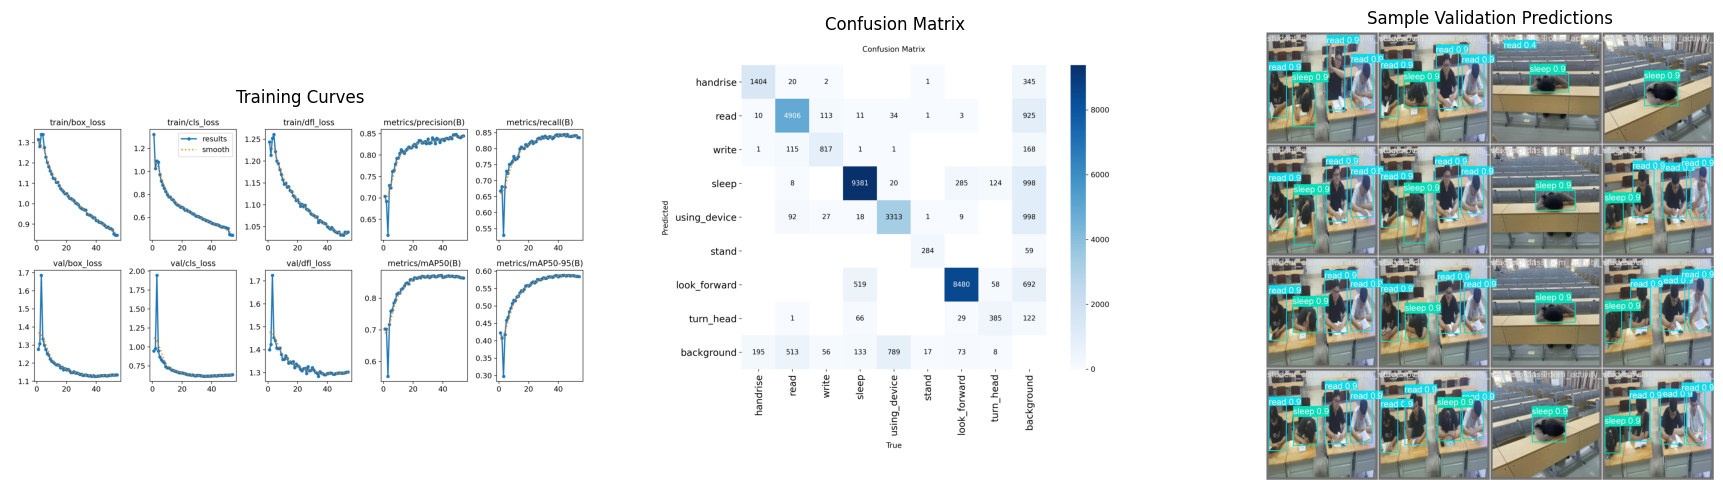

In [9]:
results_png = RUN_DIR / 'results.png'
cm_png = RUN_DIR / 'confusion_matrix.png'
val_batch_png = RUN_DIR / 'val_batch0_pred.jpg'

print('Artifacts:')
for p in [results_png, cm_png, val_batch_png]:
    print(f"{'OK ' if p.exists() else 'MISS'} - {p}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
images = [results_png, cm_png, val_batch_png]
titles = ['Training Curves', 'Confusion Matrix', 'Sample Validation Predictions']

for ax, img_path, title in zip(axes, images, titles):
    ax.set_title(title)
    ax.axis('off')
    if img_path.exists():
        img = Image.open(img_path)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, 'Not generated yet', ha='center', va='center')

plt.tight_layout()
plt.show()

## 8. Export Kaggle Artifacts (Optional)

This cell zips your run folder so you can download it from Kaggle output files.

In [10]:
archive_base = KAGGLE_WORKING_ROOT / 'classroom_model_v2_kaggle_artifacts'
archive_path = shutil.make_archive(str(archive_base), 'zip', root_dir=str(RUN_DIR)) if RUN_DIR.exists() else None
if archive_path:
    print(f'Created artifact zip: {archive_path}')
else:
    print(f'Run directory not found: {RUN_DIR}')

Created artifact zip: /kaggle/working/classroom_model_v2_kaggle_artifacts.zip
